# Persistence skill using exactly the LIM verification samples

This notebook recalculates the **centered 3-month persistence correlation skill**
for the same samples used by the existing MATLAB-style CS-White LIM experiments:

1. moving leave-\(N\)-year-block-out evaluation for \(N=2,\ldots,7\), and
2. final-\(N\)-year-block-only evaluation for \(N=2,\ldots,7\).

It does **not** define new validation periods. For every region and lead, it reads
the corresponding LIM `PP_prediction` field and uses its finite values to identify
the exact forecast initializations included in the LIM skill calculation.

The persistence forecast is the raw standardized PP anomaly at initialization,
held constant across lead. The verifying observation is the centered 3-month PP
mean at the nominal target month. A pair contributes only when the corresponding
LIM prediction, persistence value, and observation are all finite.

The notebook saves sample-matched persistence skill NetCDF files and produces:

- 2–7-year heatmap panels,
- regional line panels comparing the six window lengths, and
- 2–7-year global maps of the latest lead with persistence correlation \(r\ge0.5\).

Regions R6, R18, R19, and R29 are excluded only from figures.

In [1]:
# ============================================================
# 0. Imports and settings
# ============================================================

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from pathlib import Path
from datetime import date
from matplotlib.colors import BoundaryNorm, ListedColormap

import cartopy.crs as ccrs
import cartopy.feature as cfeature


# ------------------------------------------------------------
# Input files
# ------------------------------------------------------------

LIM_FILE = Path(
    "/nird/datalake/NS11071K/users/yongyub/DD_BGC/LIM_CS/"
    "Cyclostationary_LIM_ORAS5_XRO10_GlobColour_"
    "PP_RECCAP2_all_regions_valid_zero30_1998_2025.nc"
)

SKILL_DIR = Path(
    "/nird/datalake/NS11071K/users/yongyub/DD_BGC/LIM_CS/skill"
)

VALID_MASK_FILE = Path(
    "/nird/datalake/NS11071K/users/yongyub/Observation/GlobColour/"
    "GlobColour_PP_grid_validity_RECCAP2_all_regions/"
    "valid_mask_zero30/"
    "RECCAP2_all_regions_valid_mask_zero30_on_PPgrid.nc"
)


# ------------------------------------------------------------
# Analysis settings
# ------------------------------------------------------------

WINDOW_YEARS = np.arange(2, 8, dtype=int)

TARGET_STATE = "PP"
THRESHOLD = 0.5

EXCLUDE_REGIONS = [6, 18, 19, 29]

SAVE_FIGURES = False

CENTRAL_LONGITUDE = 210
PLOT_STRIDE = 4
DISPLAY_MAX_LEAD = 15

BASIN_ORDER = [
    "Pacific Ocean",
    "Indian Ocean",
    "Atlantic Ocean",
    "Southern Ocean",
    "Arctic Ocean",
]

BASIN_SHORT = {
    "Pacific Ocean": "PO",
    "Indian Ocean": "IO",
    "Atlantic Ocean": "AO",
    "Southern Ocean": "SO",
    "Arctic Ocean": "ArO",
}


# ------------------------------------------------------------
# Existing LIM prediction files
# ------------------------------------------------------------

def moving_cv_file(window_years):
    return SKILL_DIR / (
        "Cyclostationary_LIM_MATLABstyle_CSWhite_PP_forecast_skill_23month_"
        f"3month_running_mean_leave{int(window_years)}yearblockout_"
        "corr_threshold05_RECCAP2_all_regions_valid_zero30.nc"
    )


def last_block_file(window_years):
    return SKILL_DIR / (
        "Cyclostationary_LIM_MATLABstyle_CSWhite_PP_forecast_skill_23month_"
        f"3month_running_mean_last{int(window_years)}yearblock_"
        "corr_threshold05_RECCAP2_all_regions_valid_zero30.nc"
    )


# ------------------------------------------------------------
# New sample-matched persistence files
# ------------------------------------------------------------

def persistence_output_file(design, window_years):
    window_years = int(window_years)

    if design == "moving_cv":
        design_text = f"leave{window_years}yearblockout"
    elif design == "last_block":
        design_text = f"last{window_years}yearblock"
    else:
        raise ValueError(f"Unknown design: {design}")

    return SKILL_DIR / (
        "Persistence_PP_forecast_skill_23month_"
        f"3month_running_mean_samplematched_{design_text}_"
        "corr_threshold05_RECCAP2_all_regions_valid_zero30.nc"
    )


FIG_DIR = SKILL_DIR / "Persistence_samplematched_windowCV_vs_lastblock"
FIG_DIR.mkdir(parents=True, exist_ok=True)


designs = {
    "moving_cv": {
        "file_function": moving_cv_file,
        "title": "Moving blocked cross-validation",
        "short_title": "moving CV",
    },
    "last_block": {
        "file_function": last_block_file,
        "title": "Final-block validation only",
        "short_title": "last block",
    },
}

In [2]:
# ============================================================
# 1. Helper functions
# ============================================================

def decode_strings(values):
    values = np.asarray(values)

    return np.asarray(
        [
            value.decode("utf-8")
            if isinstance(value, (bytes, np.bytes_))
            else str(value)
            for value in values
        ],
        dtype=object,
    )


def decode_str(value):
    if isinstance(value, (bytes, np.bytes_)):
        return value.decode("utf-8")

    arr = np.asarray(value)

    if arr.shape == ():
        item = arr.item()

        if isinstance(item, (bytes, np.bytes_)):
            return item.decode("utf-8")

        return str(item)

    return str(value)


def centered_mean_3_timeseries(values):
    """
    Strict centered 3-month mean along one continuous monthly time series.

    At time t, the result is mean(values[t-1:t+2]).
    All three months must be finite.
    """
    values = np.asarray(values, dtype=float)

    result = np.full(
        values.shape,
        np.nan,
        dtype=float,
    )

    if values.size < 3:
        return result

    window = np.vstack(
        [
            values[:-2],
            values[1:-1],
            values[2:],
        ]
    )

    valid = np.isfinite(window).all(axis=0)

    inner = result[1:-1]
    inner[valid] = np.mean(
        window[:, valid],
        axis=0,
    )
    result[1:-1] = inner

    return result


def corr_1d(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)

    valid = np.isfinite(a) & np.isfinite(b)

    if valid.sum() < 3:
        return np.nan

    aa = a[valid]
    bb = b[valid]

    if np.std(aa) == 0 or np.std(bb) == 0:
        return np.nan

    return float(
        np.corrcoef(aa, bb)[0, 1]
    )


def latest_any_skillful_lead(skill, leads, threshold=0.5):
    """
    Latest lead anywhere with skill >= threshold.

    This matches the existing correlation-skill map convention:
    an isolated late-lead recovery is counted.
    """
    skill = np.asarray(skill, dtype=float)
    leads = np.asarray(leads, dtype=int)

    good = np.where(
        np.isfinite(skill)
        & (skill >= threshold)
    )[0]

    if good.size == 0:
        return 0

    return int(leads[good[-1]])


def latest_contiguous_skillful_lead(skill, leads, threshold=0.5):
    """
    Latest uninterrupted lead from lead 1 with skill >= threshold.

    Saved as a diagnostic, but the maps below use latest_any_skillful_lead
    to match the existing LIM correlation maps.
    """
    skill = np.asarray(skill, dtype=float)
    leads = np.asarray(leads, dtype=int)

    latest = 0

    for value, lead in zip(skill, leads):
        if not np.isfinite(value) or value < threshold:
            break

        latest = int(lead)

    return latest


def get_basin_name(ds, region):
    if "basin" not in ds:
        return "Unknown"

    try:
        raw = decode_str(
            ds["basin"]
            .sel(region=int(region))
            .values
        ).strip()
    except Exception:
        return "Unknown"

    lower = raw.lower()

    if "pacific" in lower:
        return "Pacific Ocean"

    if "indian" in lower:
        return "Indian Ocean"

    if "atlantic" in lower:
        return "Atlantic Ocean"

    if "southern" in lower:
        return "Southern Ocean"

    if "arctic" in lower:
        return "Arctic Ocean"

    return raw


def get_region_label(ds, region, short=True):
    region = int(region)

    if "region_name" in ds:
        try:
            name = decode_str(
                ds["region_name"]
                .sel(region=region)
                .values
            )
        except Exception:
            name = f"region {region}"
    else:
        name = f"region {region}"

    if short:
        return f"R{region}. {name}"

    return f"R{region}: {name}"


def lon_to_180(lon):
    return ((float(lon) + 180.0) % 360.0) - 180.0


def weighted_centroid(lon, lat, region_mask):
    lon2d, lat2d = np.meshgrid(lon, lat)
    region_mask = np.asarray(region_mask, dtype=bool)

    if not np.any(region_mask):
        return np.nan, np.nan

    weights = np.cos(
        np.deg2rad(lat2d[region_mask])
    )

    lat_c = np.average(
        lat2d[region_mask],
        weights=weights,
    )

    lon_rad = np.deg2rad(
        lon2d[region_mask]
    )

    x = np.average(
        np.cos(lon_rad),
        weights=weights,
    )

    y = np.average(
        np.sin(lon_rad),
        weights=weights,
    )

    lon_c = (
        np.rad2deg(
            np.arctan2(y, x)
        )
        % 360.0
    )

    return lon_c, lat_c


def add_cyclic_manual(data, lon):
    data = np.asarray(data)
    lon = np.asarray(lon, dtype=float)

    sort_index = np.argsort(lon)
    lon_sorted = lon[sort_index]
    data_sorted = data[:, sort_index]

    dlon = float(
        np.nanmedian(
            np.diff(lon_sorted)
        )
    )

    lon_cyclic = np.concatenate(
        [
            lon_sorted,
            [lon_sorted[-1] + dlon],
        ]
    )

    data_cyclic = np.concatenate(
        [
            data_sorted,
            data_sorted[:, :1],
        ],
        axis=1,
    )

    return data_cyclic, lon_cyclic

In [3]:
# ============================================================
# 2. Load raw and centered 3-month PP observations
# ============================================================

if not LIM_FILE.exists():
    raise FileNotFoundError(
        f"LIM state-vector file not found:\n{LIM_FILE}"
    )

with xr.open_dataset(LIM_FILE) as ds:
    ds_lim = ds.load()


state_vector = ds_lim[
    "state_vector"
].transpose(
    "region",
    "time",
    "state",
)

regions = state_vector[
    "region"
].values.astype(np.int16)

times = state_vector[
    "time"
].values

states = decode_strings(
    state_vector["state"].values
)

target_match = np.where(
    states == TARGET_STATE
)[0]

if target_match.size != 1:
    raise ValueError(
        f"TARGET_STATE={TARGET_STATE!r} is not unique: "
        f"{list(states)}"
    )

target_index = int(
    target_match[0]
)

n_region = len(regions)
n_time = len(times)


obs_pp_raw_values = np.full(
    (n_region, n_time),
    np.nan,
    dtype=np.float32,
)

obs_pp_3month_values = np.full(
    (n_region, n_time),
    np.nan,
    dtype=np.float32,
)


for ir, region in enumerate(regions):
    raw = (
        state_vector
        .sel(region=region)
        .values[:, target_index]
        .astype(float)
    )

    obs_pp_raw_values[ir] = (
        raw.astype(np.float32)
    )

    obs_pp_3month_values[ir] = (
        centered_mean_3_timeseries(raw)
        .astype(np.float32)
    )


obs_pp_raw = xr.DataArray(
    obs_pp_raw_values,
    dims=("region", "time"),
    coords={
        "region": regions,
        "time": times,
    },
    name="PP_observation_raw_standardized",
)

obs_pp_3month = xr.DataArray(
    obs_pp_3month_values,
    dims=("region", "time"),
    coords={
        "region": regions,
        "time": times,
    },
    name="PP_observation_centered_3month",
)


print("State-vector file:", LIM_FILE)
print("Regions:", regions)
print("Number of months:", n_time)
print(
    "Time range:",
    pd.Timestamp(times[0]).strftime("%Y-%m"),
    "to",
    pd.Timestamp(times[-1]).strftime("%Y-%m"),
)

State-vector file: /nird/datalake/NS11071K/users/yongyub/DD_BGC/LIM_CS/Cyclostationary_LIM_ORAS5_XRO10_GlobColour_PP_RECCAP2_all_regions_valid_zero30_1998_2025.nc
Regions: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 18 19 27 28 29]
Number of months: 336
Time range: 1998-01 to 2025-12


In [4]:
# ============================================================
# 3. Calculate and save sample-matched persistence skill
# ============================================================

persistence_datasets = {
    "moving_cv": {},
    "last_block": {},
}


for design, design_info in designs.items():

    print("\n" + "=" * 80)
    print(design_info["title"])
    print("=" * 80)

    file_function = design_info[
        "file_function"
    ]

    for window_years in WINDOW_YEARS:
        window_years = int(window_years)

        lim_skill_file = file_function(
            window_years
        )

        if not lim_skill_file.exists():
            raise FileNotFoundError(
                f"LIM prediction file not found for "
                f"{design}, {window_years} years:\n"
                f"{lim_skill_file}"
            )

        with xr.open_dataset(
            lim_skill_file
        ) as ds:
            ds_prediction = ds.load()


        if "PP_prediction" not in ds_prediction:
            raise KeyError(
                f"PP_prediction not found in:\n"
                f"{lim_skill_file}"
            )


        lim_prediction = ds_prediction[
            "PP_prediction"
        ].transpose(
            "region",
            "init_time",
            "lead",
        )


        # ----------------------------------------------------
        # Coordinate checks
        # ----------------------------------------------------

        prediction_times = pd.DatetimeIndex(
            pd.to_datetime(
                lim_prediction[
                    "init_time"
                ].values
            )
        )

        observation_times = pd.DatetimeIndex(
            pd.to_datetime(times)
        )

        if not prediction_times.equals(
            observation_times
        ):
            raise ValueError(
                f"init_time mismatch in:\n"
                f"{lim_skill_file}"
            )


        prediction_regions = (
            lim_prediction[
                "region"
            ].values.astype(np.int16)
        )

        if not np.array_equal(
            prediction_regions,
            regions,
        ):
            raise ValueError(
                f"Region mismatch in:\n"
                f"{lim_skill_file}\n"
                f"Prediction regions: {prediction_regions}\n"
                f"State-vector regions: {regions}"
            )


        leads = lim_prediction[
            "lead"
        ].values.astype(np.int16)

        n_lead = len(leads)


        # ----------------------------------------------------
        # Output arrays
        # ----------------------------------------------------

        persistence_prediction = np.full(
            (
                n_region,
                n_time,
                n_lead,
            ),
            np.nan,
            dtype=np.float32,
        )

        matched_observation = np.full(
            (
                n_region,
                n_time,
                n_lead,
            ),
            np.nan,
            dtype=np.float32,
        )

        sample_used = np.zeros(
            (
                n_region,
                n_time,
                n_lead,
            ),
            dtype=np.int8,
        )

        persistence_skill = np.full(
            (
                n_region,
                n_lead,
            ),
            np.nan,
            dtype=np.float32,
        )

        n_pairs = np.zeros(
            (
                n_region,
                n_lead,
            ),
            dtype=np.int16,
        )


        # ----------------------------------------------------
        # Exact LIM-sample matching
        # ----------------------------------------------------

        for ir, region in enumerate(regions):

            raw_pp = (
                obs_pp_raw
                .sel(region=region)
                .values
                .astype(float)
            )

            observed_3month = (
                obs_pp_3month
                .sel(region=region)
                .values
                .astype(float)
            )

            lim_region = (
                lim_prediction
                .sel(region=region)
                .values
                .astype(float)
            )


            for il, lead in enumerate(leads):

                init_indices = np.arange(
                    n_time,
                    dtype=int,
                )

                target_indices = (
                    init_indices
                    + int(lead)
                )

                in_range = (
                    target_indices
                    < n_time
                )

                init_valid = (
                    init_indices[in_range]
                )

                target_valid = (
                    target_indices[in_range]
                )


                # The LIM file already contains centered
                # 3-month predictions. Its finite mask therefore
                # identifies the exact samples used by that LIM
                # experiment at this region and lead.
                lim_values = lim_region[
                    init_valid,
                    il,
                ]

                persistence_values = raw_pp[
                    init_valid
                ]

                observation_values = observed_3month[
                    target_valid
                ]


                exact_sample = (
                    np.isfinite(lim_values)
                    & np.isfinite(
                        persistence_values
                    )
                    & np.isfinite(
                        observation_values
                    )
                )


                selected_init = init_valid[
                    exact_sample
                ]

                selected_persistence = (
                    persistence_values[
                        exact_sample
                    ]
                )

                selected_observation = (
                    observation_values[
                        exact_sample
                    ]
                )


                persistence_prediction[
                    ir,
                    selected_init,
                    il,
                ] = selected_persistence.astype(
                    np.float32
                )

                matched_observation[
                    ir,
                    selected_init,
                    il,
                ] = selected_observation.astype(
                    np.float32
                )

                sample_used[
                    ir,
                    selected_init,
                    il,
                ] = 1


                n_pairs[
                    ir,
                    il,
                ] = int(
                    exact_sample.sum()
                )

                persistence_skill[
                    ir,
                    il,
                ] = corr_1d(
                    selected_persistence,
                    selected_observation,
                )


        # ----------------------------------------------------
        # Verify equality with the LIM n_pairs
        # ----------------------------------------------------

        if "n_pairs" in ds_prediction:
            lim_n_pairs = (
                ds_prediction["n_pairs"]
                .sel(
                    region=regions,
                    lead=leads,
                )
                .values
                .astype(int)
            )

            if not np.array_equal(
                n_pairs.astype(int),
                lim_n_pairs,
            ):
                difference = (
                    n_pairs.astype(int)
                    - lim_n_pairs
                )

                mismatch = np.argwhere(
                    difference != 0
                )

                first = mismatch[0]

                raise ValueError(
                    "Persistence and LIM samples do not match.\n"
                    f"File: {lim_skill_file}\n"
                    f"First mismatch: "
                    f"region={regions[first[0]]}, "
                    f"lead={leads[first[1]]}, "
                    f"persistence n={n_pairs[tuple(first)]}, "
                    f"LIM n={lim_n_pairs[tuple(first)]}"
                )


        latest_any = np.asarray(
            [
                latest_any_skillful_lead(
                    persistence_skill[ir],
                    leads,
                    threshold=THRESHOLD,
                )
                for ir in range(n_region)
            ],
            dtype=np.int16,
        )

        latest_contiguous = np.asarray(
            [
                latest_contiguous_skillful_lead(
                    persistence_skill[ir],
                    leads,
                    threshold=THRESHOLD,
                )
                for ir in range(n_region)
            ],
            dtype=np.int16,
        )


        # ----------------------------------------------------
        # Metadata inherited from the LIM prediction file
        # ----------------------------------------------------

        data_vars = {
            "PP_prediction_persistence": (
                (
                    "region",
                    "init_time",
                    "lead",
                ),
                persistence_prediction,
                {
                    "long_name": (
                        "Sample-matched persistence forecast "
                        "of standardized PP"
                    ),
                    "description": (
                        "Raw standardized PP at initialization, "
                        "held constant across lead and retained "
                        "only where the corresponding LIM forecast "
                        "and centered 3-month observation are valid."
                    ),
                    "units": "standard deviation",
                },
            ),

            "PP_observation_3month_samplematched": (
                (
                    "region",
                    "init_time",
                    "lead",
                ),
                matched_observation,
                {
                    "long_name": (
                        "Sample-matched centered 3-month "
                        "observed PP"
                    ),
                    "description": (
                        "Centered 3-month observed PP at the "
                        "nominal target month, stored only for "
                        "the exact samples used by the LIM."
                    ),
                    "units": "standard deviation",
                },
            ),

            "sample_used": (
                (
                    "region",
                    "init_time",
                    "lead",
                ),
                sample_used,
                {
                    "long_name": (
                        "Exact LIM verification-sample indicator"
                    ),
                    "description": (
                        "One where the corresponding LIM "
                        "prediction, persistence forecast, and "
                        "centered 3-month observation are all "
                        "finite; zero otherwise."
                    ),
                },
            ),

            "PP_correlation_skill_persistence": (
                (
                    "region",
                    "lead",
                ),
                persistence_skill,
                {
                    "long_name": (
                        "Sample-matched persistence PP "
                        "correlation skill"
                    ),
                    "description": (
                        "Pearson correlation between persistence "
                        "and centered 3-month observed PP using "
                        "exactly the same samples as the "
                        "corresponding LIM skill calculation."
                    ),
                    "threshold_reference": THRESHOLD,
                },
            ),

            "n_pairs": (
                (
                    "region",
                    "lead",
                ),
                n_pairs,
                {
                    "long_name": (
                        "Number of exact sample-matched "
                        "forecast-observation pairs"
                    ),
                },
            ),

            "latest_lead_corr_ge_05_persistence": (
                ("region",),
                latest_any,
                {
                    "long_name": (
                        "Latest lead anywhere with sample-matched "
                        "persistence correlation >= 0.5"
                    ),
                    "units": "month",
                },
            ),

            "latest_contiguous_lead_corr_ge_05_persistence": (
                ("region",),
                latest_contiguous,
                {
                    "long_name": (
                        "Latest uninterrupted lead from lead 1 "
                        "with sample-matched persistence "
                        "correlation >= 0.5"
                    ),
                    "units": "month",
                },
            ),
        }


        for name in [
            "region_name",
            "basin",
            "original_region_id",
        ]:
            if name in ds_prediction:
                data_vars[name] = (
                    ds_prediction[name]
                )
            elif name in ds_lim:
                data_vars[name] = (
                    ds_lim[name]
                    .sel(region=regions)
                )


        ds_persistence = xr.Dataset(
            data_vars=data_vars,
            coords={
                "region": regions,
                "init_time": times,
                "lead": leads,
            },
            attrs={
                "title": (
                    "Persistence PP correlation skill using "
                    "exactly the LIM verification samples"
                ),
                "lim_prediction_source_file": str(
                    lim_skill_file
                ),
                "state_vector_source_file": str(
                    LIM_FILE
                ),
                "validation_design": design,
                "window_years": window_years,
                "target_state": TARGET_STATE,
                "correlation_threshold": THRESHOLD,
                "running_mean_window_months": 3,
                "running_mean_alignment": "centered",
                "persistence_definition": (
                    "Raw standardized PP anomaly at "
                    "initialization held constant for all leads."
                ),
                "observation_definition": (
                    "Strict centered 3-month mean of standardized "
                    "PP at the nominal target month."
                ),
                "sample_matching": (
                    "For every region and lead, the finite mask "
                    "of the corresponding LIM PP_prediction is "
                    "combined with finite persistence and "
                    "observation values. n_pairs is checked "
                    "against the LIM n_pairs and execution stops "
                    "if any mismatch occurs."
                ),
                "map_definition": (
                    "Latest lead anywhere with correlation >= 0.5, "
                    "matching the existing LIM correlation-map convention."
                ),
                "date_created": date.today().isoformat(),
            },
        )


        # Copy useful validation masks when present.
        for name in [
            "used_as_validation_initialization",
            "validation_fold_for_time",
            "used_for_training",
        ]:
            if name in ds_prediction:
                ds_persistence[name] = (
                    ds_prediction[name]
                )


        encoding = {
            "PP_prediction_persistence": {
                "dtype": "float32",
                "_FillValue": np.float32(-999.0),
                "zlib": True,
                "complevel": 4,
            },

            "PP_observation_3month_samplematched": {
                "dtype": "float32",
                "_FillValue": np.float32(-999.0),
                "zlib": True,
                "complevel": 4,
            },

            "sample_used": {
                "dtype": "int8",
                "_FillValue": None,
                "zlib": True,
                "complevel": 4,
            },

            "PP_correlation_skill_persistence": {
                "dtype": "float32",
                "_FillValue": np.float32(-999.0),
                "zlib": True,
                "complevel": 4,
            },

            "n_pairs": {
                "dtype": "int16",
                "_FillValue": None,
            },

            "latest_lead_corr_ge_05_persistence": {
                "dtype": "int16",
                "_FillValue": None,
            },

            "latest_contiguous_lead_corr_ge_05_persistence": {
                "dtype": "int16",
                "_FillValue": None,
            },

            "region": {
                "dtype": "int16",
                "_FillValue": None,
            },

            "lead": {
                "dtype": "int16",
                "_FillValue": None,
            },

            "init_time": {
                "dtype": "float64",
                "units": "days since 1900-01-01",
                "calendar": "gregorian",
            },
        }


        if "original_region_id" in ds_persistence:
            encoding[
                "original_region_id"
            ] = {
                "dtype": "int16",
                "_FillValue": None,
            }


        for name in [
            "used_as_validation_initialization",
            "used_for_training",
        ]:
            if name in ds_persistence:
                encoding[name] = {
                    "dtype": "int8",
                    "_FillValue": None,
                }


        if (
            "validation_fold_for_time"
            in ds_persistence
        ):
            encoding[
                "validation_fold_for_time"
            ] = {
                "dtype": "int16",
                "_FillValue": None,
            }


        output_file = persistence_output_file(
            design,
            window_years,
        )

        if output_file.exists():
            output_file.unlink()


        ds_persistence.to_netcdf(
            output_file,
            encoding=encoding,
            engine="netcdf4",
        )


        persistence_datasets[
            design
        ][window_years] = (
            ds_persistence
        )


        print(
            f"{window_years}-year window: "
            f"saved {output_file.name}; "
            f"n_pairs="
            f"{int(np.nanmin(n_pairs))}–"
            f"{int(np.nanmax(n_pairs))}"
        )


Moving blocked cross-validation
2-year window: saved Persistence_PP_forecast_skill_23month_3month_running_mean_samplematched_leave2yearblockout_corr_threshold05_RECCAP2_all_regions_valid_zero30.nc; n_pairs=312–334
3-year window: saved Persistence_PP_forecast_skill_23month_3month_running_mean_samplematched_leave3yearblockout_corr_threshold05_RECCAP2_all_regions_valid_zero30.nc; n_pairs=312–334
4-year window: saved Persistence_PP_forecast_skill_23month_3month_running_mean_samplematched_leave4yearblockout_corr_threshold05_RECCAP2_all_regions_valid_zero30.nc; n_pairs=312–334
5-year window: saved Persistence_PP_forecast_skill_23month_3month_running_mean_samplematched_leave5yearblockout_corr_threshold05_RECCAP2_all_regions_valid_zero30.nc; n_pairs=312–334
6-year window: saved Persistence_PP_forecast_skill_23month_3month_running_mean_samplematched_leave6yearblockout_corr_threshold05_RECCAP2_all_regions_valid_zero30.nc; n_pairs=312–334
7-year window: saved Persistence_PP_forecast_skill_23mont

In [5]:
# ============================================================
# 4. Plotting setup
# ============================================================

# Load outputs from disk when plotting is run independently.
if (
    "persistence_datasets" not in globals()
    or not persistence_datasets
):
    persistence_datasets = {
        "moving_cv": {},
        "last_block": {},
    }


for design in designs:
    for window_years in WINDOW_YEARS:
        window_years = int(window_years)

        if (
            window_years
            not in persistence_datasets[design]
        ):
            output_file = persistence_output_file(
                design,
                window_years,
            )

            if not output_file.exists():
                raise FileNotFoundError(
                    f"Persistence result not found:\n"
                    f"{output_file}\n"
                    "Run the calculation cell first."
                )

            with xr.open_dataset(
                output_file
            ) as ds:
                persistence_datasets[
                    design
                ][window_years] = ds.load()


reference_ds = persistence_datasets[
    "moving_cv"
][int(WINDOW_YEARS[0])]


keep_regions = [
    int(region)
    for region in reference_ds[
        "region"
    ].values
    if int(region) not in EXCLUDE_REGIONS
]


region_basin = {
    int(region): get_basin_name(
        reference_ds,
        region,
    )
    for region in keep_regions
}


basin_rank = {
    basin: index
    for index, basin
    in enumerate(BASIN_ORDER)
}


regions_plot = np.asarray(
    sorted(
        keep_regions,
        key=lambda region: (
            basin_rank.get(
                region_basin[region],
                len(BASIN_ORDER),
            ),
            region,
        ),
    ),
    dtype=np.int16,
)


n_region_plot = len(
    regions_plot
)

leads = reference_ds[
    "lead"
].values.astype(np.int16)


basin_groups = []

for basin in BASIN_ORDER:
    indices = [
        index
        for index, region
        in enumerate(regions_plot)
        if (
            region_basin[int(region)]
            == basin
        )
    ]

    if indices:
        basin_groups.append(
            {
                "name": basin,
                "start": min(indices),
                "end": max(indices),
            }
        )


def add_basin_axis(ax):
    centers = [
        0.5
        * (
            group["start"]
            + group["end"]
            + 1
        )
        for group in basin_groups
    ]

    labels = [
        BASIN_SHORT.get(
            group["name"],
            group["name"],
        )
        for group in basin_groups
    ]

    axis = ax.twinx()
    axis.set_ylim(0, n_region_plot)
    axis.set_yticks(centers)
    axis.set_yticklabels(
        labels,
        fontsize=10,
        fontweight="bold",
    )
    axis.tick_params(
        axis="y",
        which="both",
        length=0,
        pad=4,
    )
    axis.set_ylabel("")

    for spine in axis.spines.values():
        spine.set_visible(False)

    return axis


print("Plotted regions:")
for region in regions_plot:
    print(
        f"  {get_region_label(reference_ds, region, short=False)} "
        f"[{region_basin[int(region)]}]"
    )

Plotted regions:
  R7: NP SPSS [Pacific Ocean]
  R8: NP STSS [Pacific Ocean]
  R9: NP STPS [Pacific Ocean]
  R10: PEQU-W [Pacific Ocean]
  R11: PEQU-E [Pacific Ocean]
  R12: SP STPS [Pacific Ocean]
  R13: Arabian Sea [Indian Ocean]
  R14: Bay of Bengal [Indian Ocean]
  R15: Equatorial Indian [Indian Ocean]
  R16: Southern Indian [Indian Ocean]
  R1: NA SPSS [Atlantic Ocean]
  R2: NA STSS [Atlantic Ocean]
  R3: NA STPS [Atlantic Ocean]
  R4: AEQU [Atlantic Ocean]
  R5: SA STPS [Atlantic Ocean]
  R27: SO STSS [Southern Ocean]
  R28: SO SPSS [Southern Ocean]


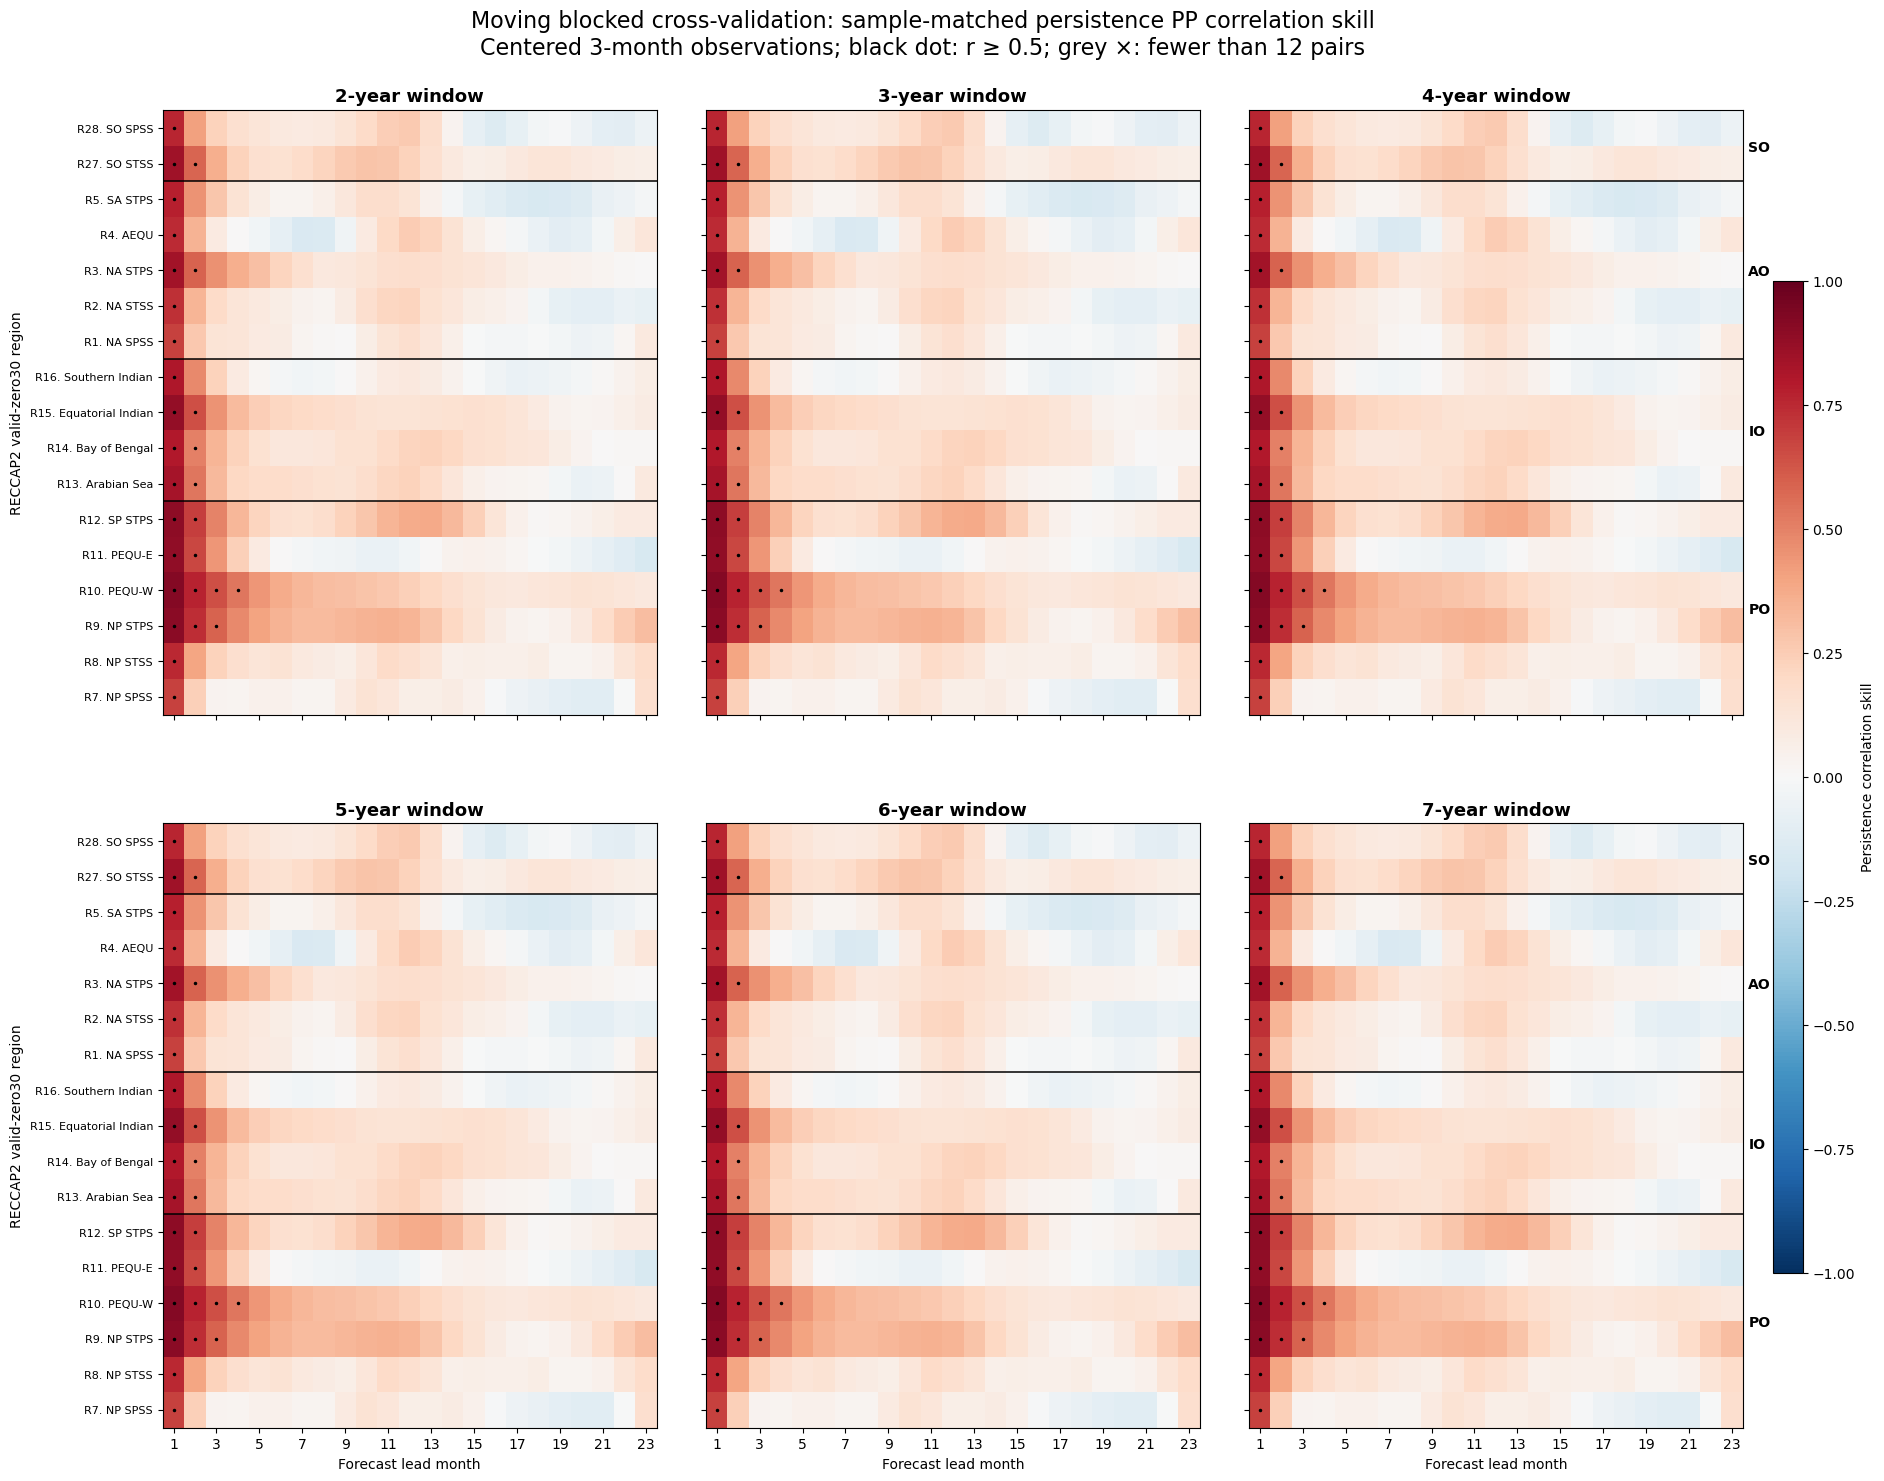

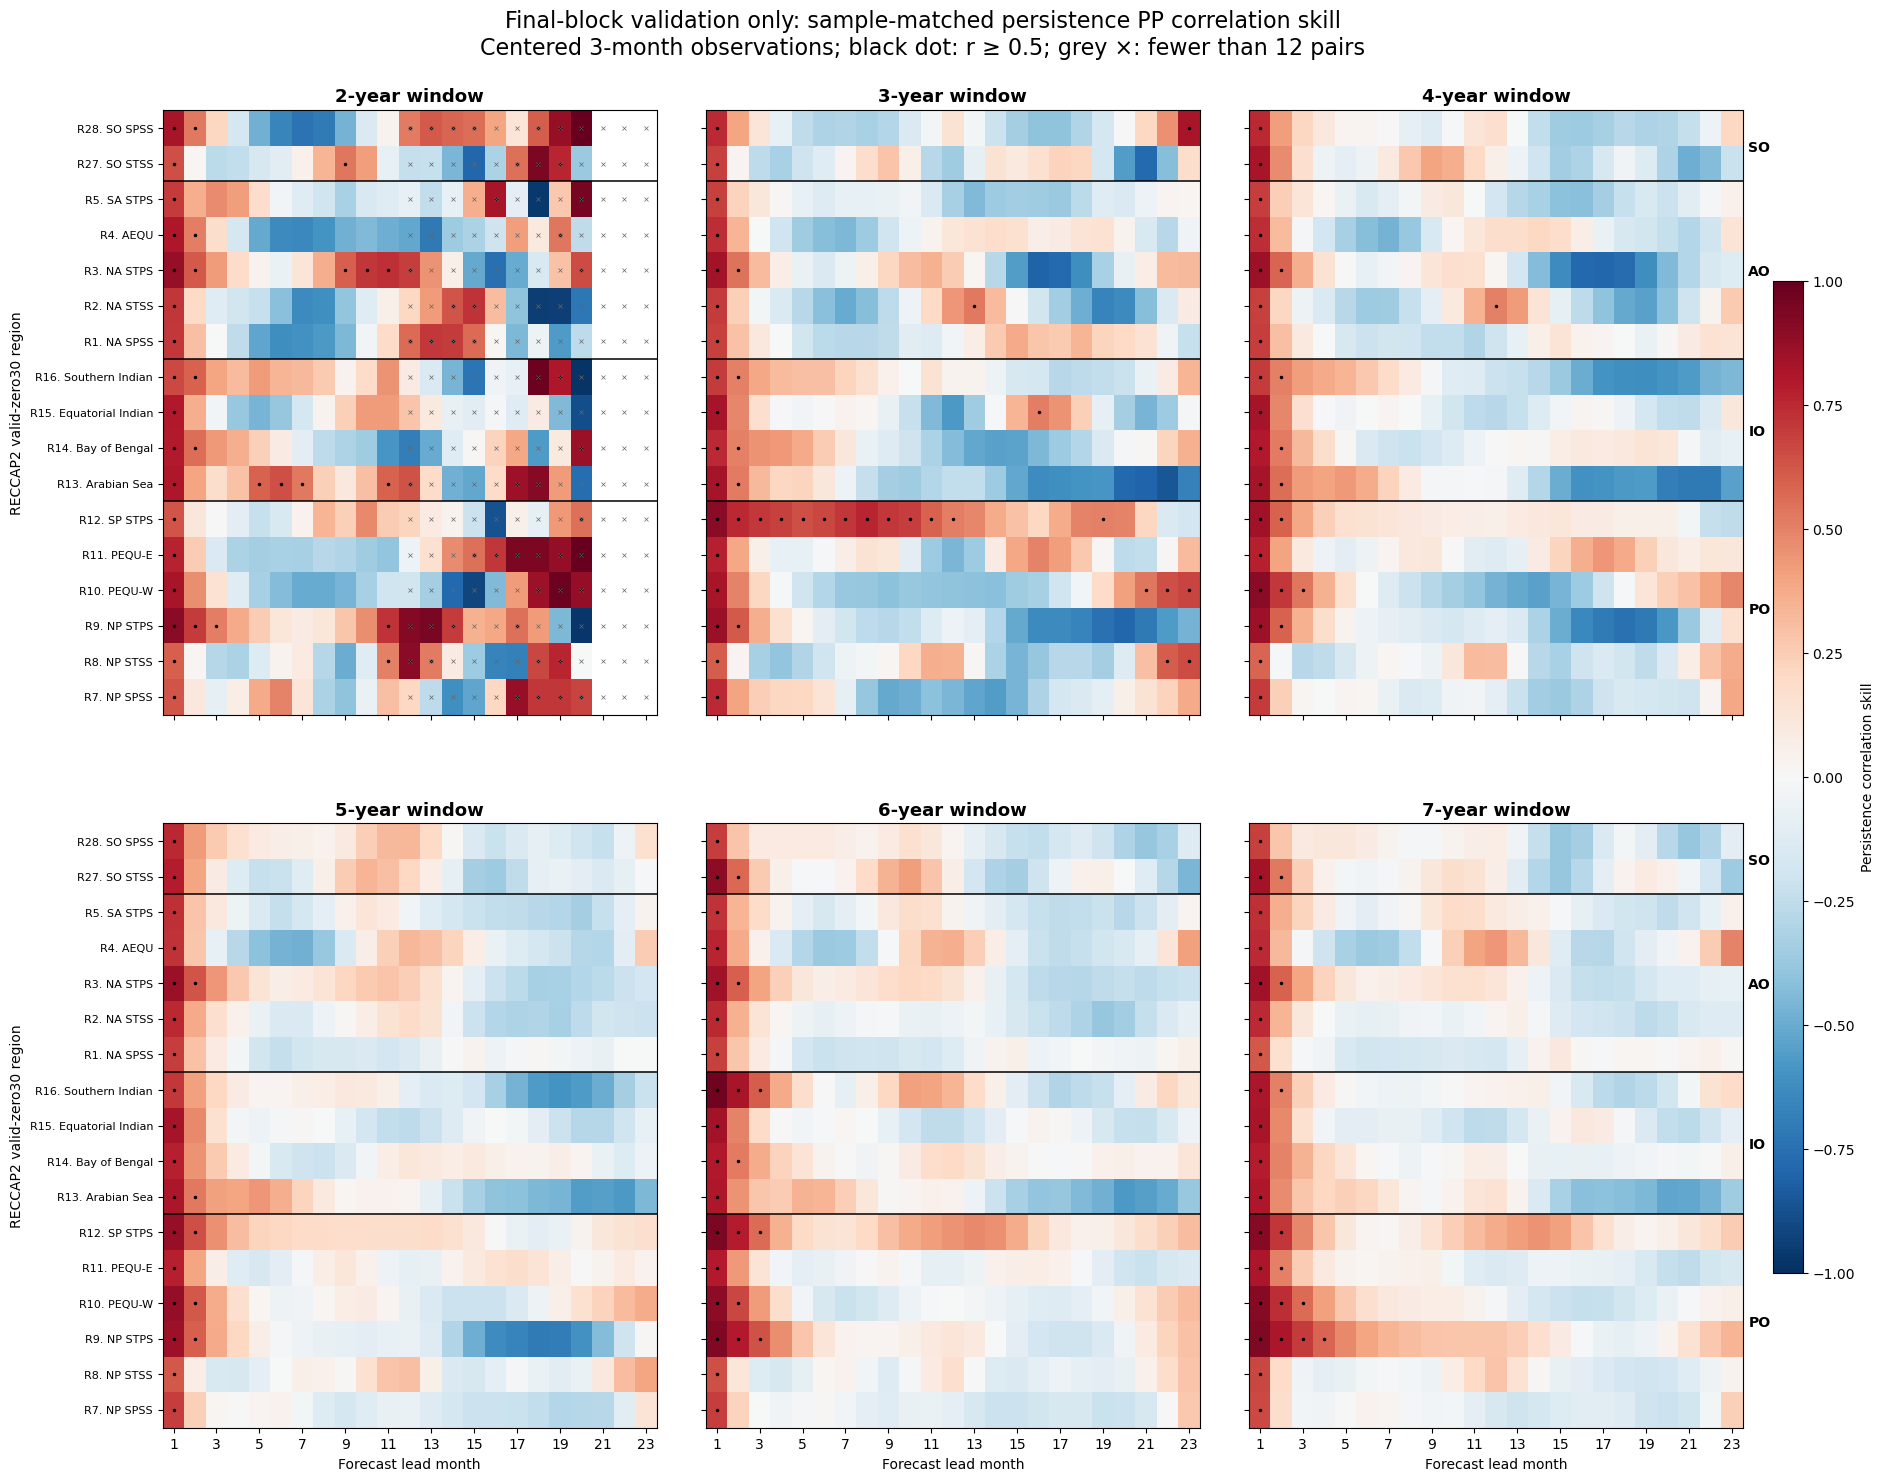

In [6]:
# ============================================================
# 5. Heatmaps: region x lead for each 2–7-year window
# ============================================================

for design, design_info in designs.items():

    fig, axes = plt.subplots(
        2,
        3,
        figsize=(
            20,
            0.50 * n_region_plot + 7.0,
        ),
        sharex=True,
        sharey=True,
    )

    axes = axes.ravel()
    last_image = None


    for panel_index, (
        ax,
        window_years,
    ) in enumerate(
        zip(
            axes,
            WINDOW_YEARS,
        )
    ):

        window_years = int(
            window_years
        )

        ds_this = persistence_datasets[
            design
        ][window_years]

        skill = (
            ds_this[
                "PP_correlation_skill_persistence"
            ]
            .sel(region=regions_plot)
        )

        n_pairs = (
            ds_this["n_pairs"]
            .sel(region=regions_plot)
        )


        y_edges = np.arange(
            n_region_plot + 1
        )

        x_edges = np.arange(
            leads[0] - 0.5,
            leads[-1] + 1.5,
            1.0,
        )


        last_image = ax.pcolormesh(
            x_edges,
            y_edges,
            skill.values,
            vmin=-1,
            vmax=1,
            cmap="RdBu_r",
            shading="auto",
        )


        # Black dots where persistence r >= 0.5.
        row_index, lead_index = np.where(
            np.isfinite(skill.values)
            & (
                skill.values
                >= THRESHOLD
            )
        )

        ax.plot(
            leads[lead_index],
            row_index + 0.5,
            "k.",
            markersize=3.0,
        )


        # Grey x where fewer than 12 pairs are available.
        small_row, small_lead = np.where(
            n_pairs.values < 12
        )

        ax.plot(
            leads[small_lead],
            small_row + 0.5,
            "x",
            color="0.40",
            markersize=2.5,
            markeredgewidth=0.5,
        )


        for group in basin_groups[:-1]:
            ax.axhline(
                group["end"] + 1,
                color="k",
                lw=1.1,
            )


        ax.set_title(
            f"{window_years}-year window",
            fontsize=13,
            fontweight="bold",
        )

        ax.set_xlim(
            leads[0] - 0.5,
            leads[-1] + 0.5,
        )

        ax.set_ylim(
            0,
            n_region_plot,
        )

        ax.set_xticks(
            np.arange(
                leads[0],
                leads[-1] + 1,
                2,
            )
        )


        if panel_index % 3 == 0:
            ax.set_ylabel(
                "RECCAP2 valid-zero30 region"
            )

            ax.set_yticks(
                np.arange(
                    n_region_plot
                )
                + 0.5
            )

            ax.set_yticklabels(
                [
                    get_region_label(
                        reference_ds,
                        region,
                        short=True,
                    )
                    for region
                    in regions_plot
                ],
                fontsize=8,
            )


        if panel_index % 3 == 2:
            add_basin_axis(ax)


        if panel_index >= 3:
            ax.set_xlabel(
                "Forecast lead month"
            )


    fig.suptitle(
        f"{design_info['title']}: sample-matched persistence PP correlation skill\n"
        "Centered 3-month observations; black dot: r ≥ 0.5; "
        "grey ×: fewer than 12 pairs",
        fontsize=16,
        y=0.995,
    )


    fig.subplots_adjust(
        left=0.12,
        right=0.91,
        top=0.93,
        bottom=0.08,
        wspace=0.10,
        hspace=0.18,
    )


    color_axis = fig.add_axes(
        [
            0.925,
            0.18,
            0.015,
            0.64,
        ]
    )

    colorbar = fig.colorbar(
        last_image,
        cax=color_axis,
    )

    colorbar.set_label(
        "Persistence correlation skill"
    )


    heatmap_file = FIG_DIR / (
        f"Persistence_PP_samplematched_{design}_"
        "2to7year_heatmaps.png"
    )


    if SAVE_FIGURES:
        fig.savefig(
            heatmap_file,
            dpi=200,
            bbox_inches="tight",
        )

        print(
            f"Saved: {heatmap_file}"
        )


    plt.show()

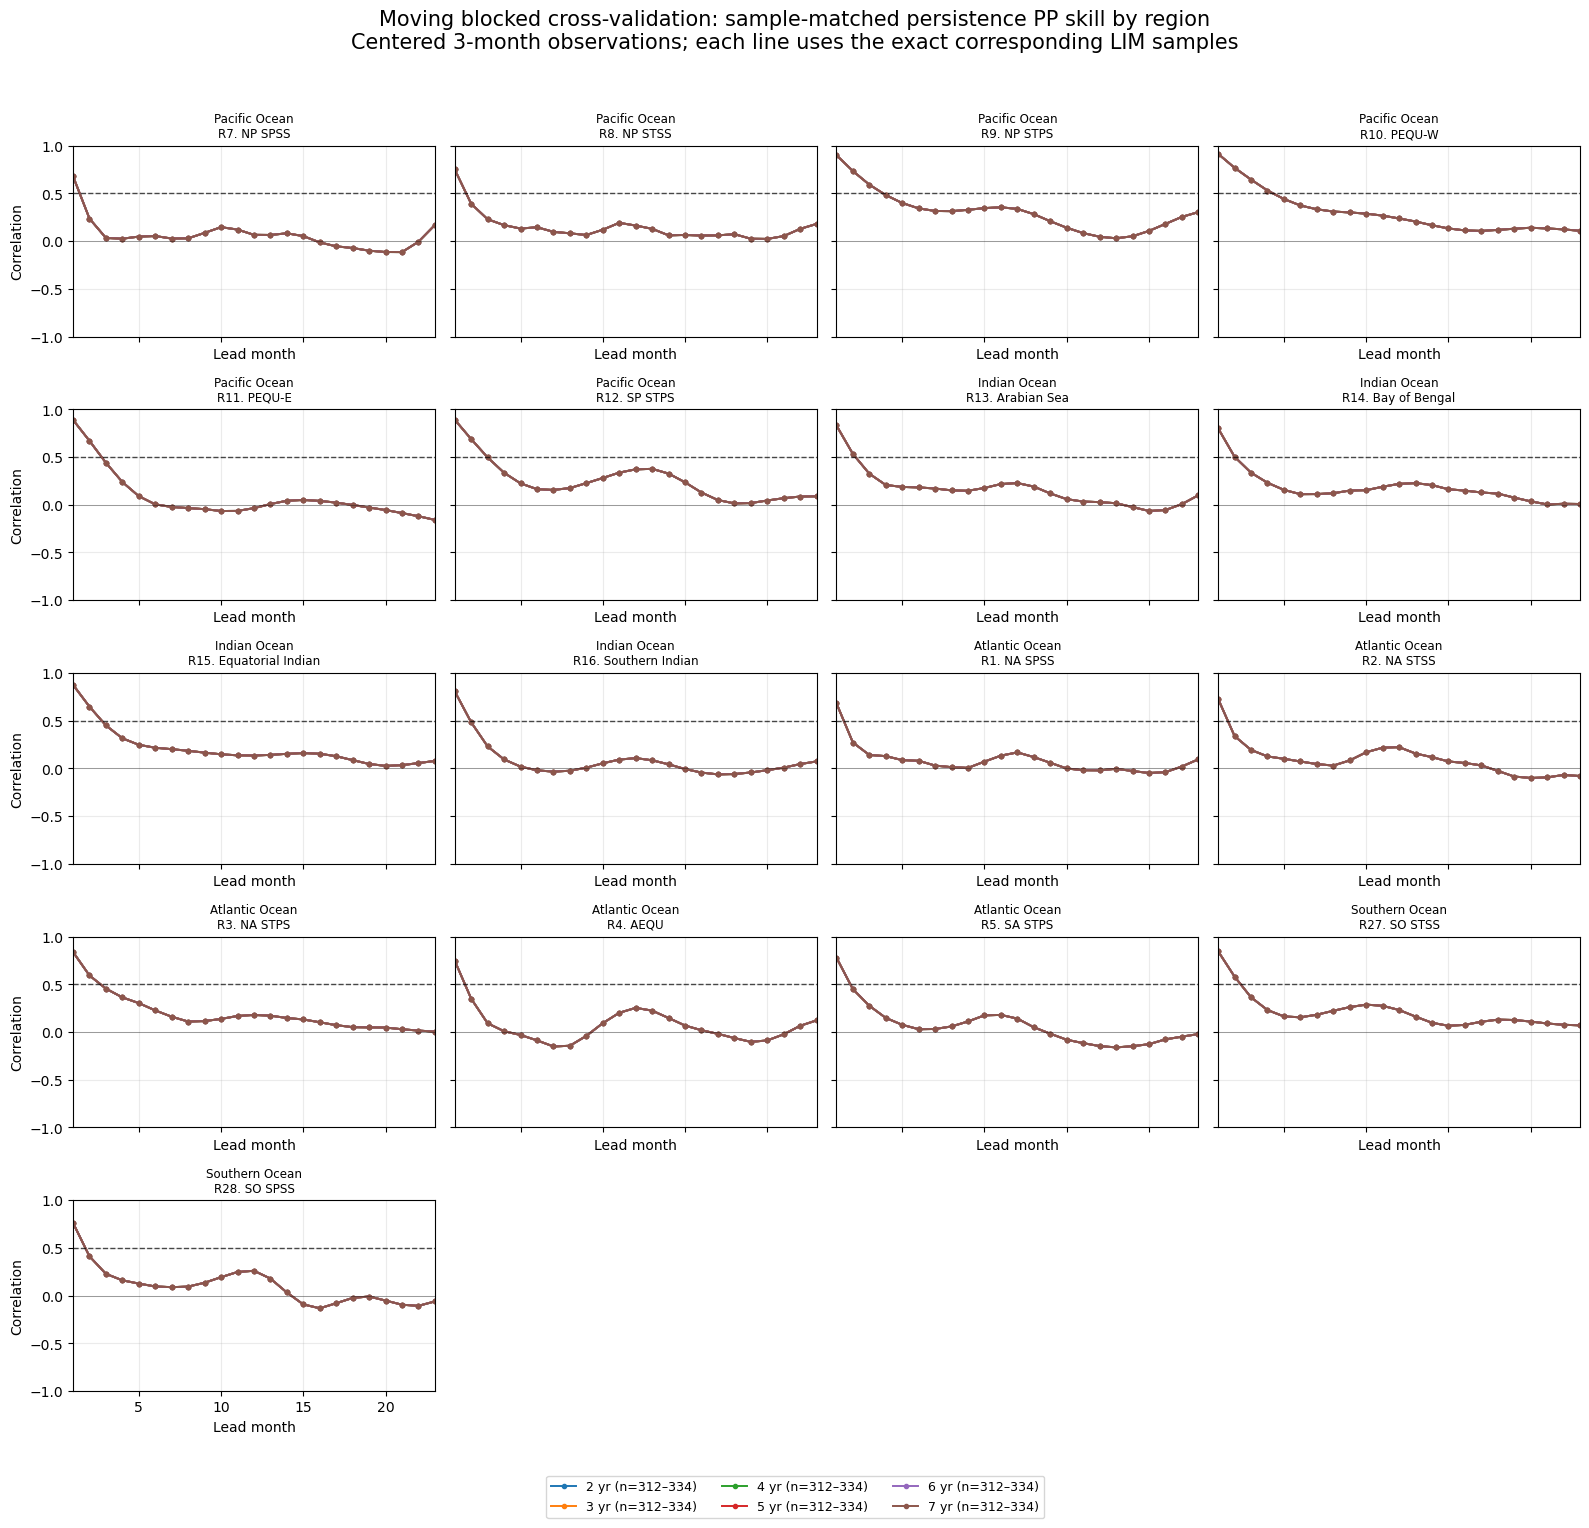

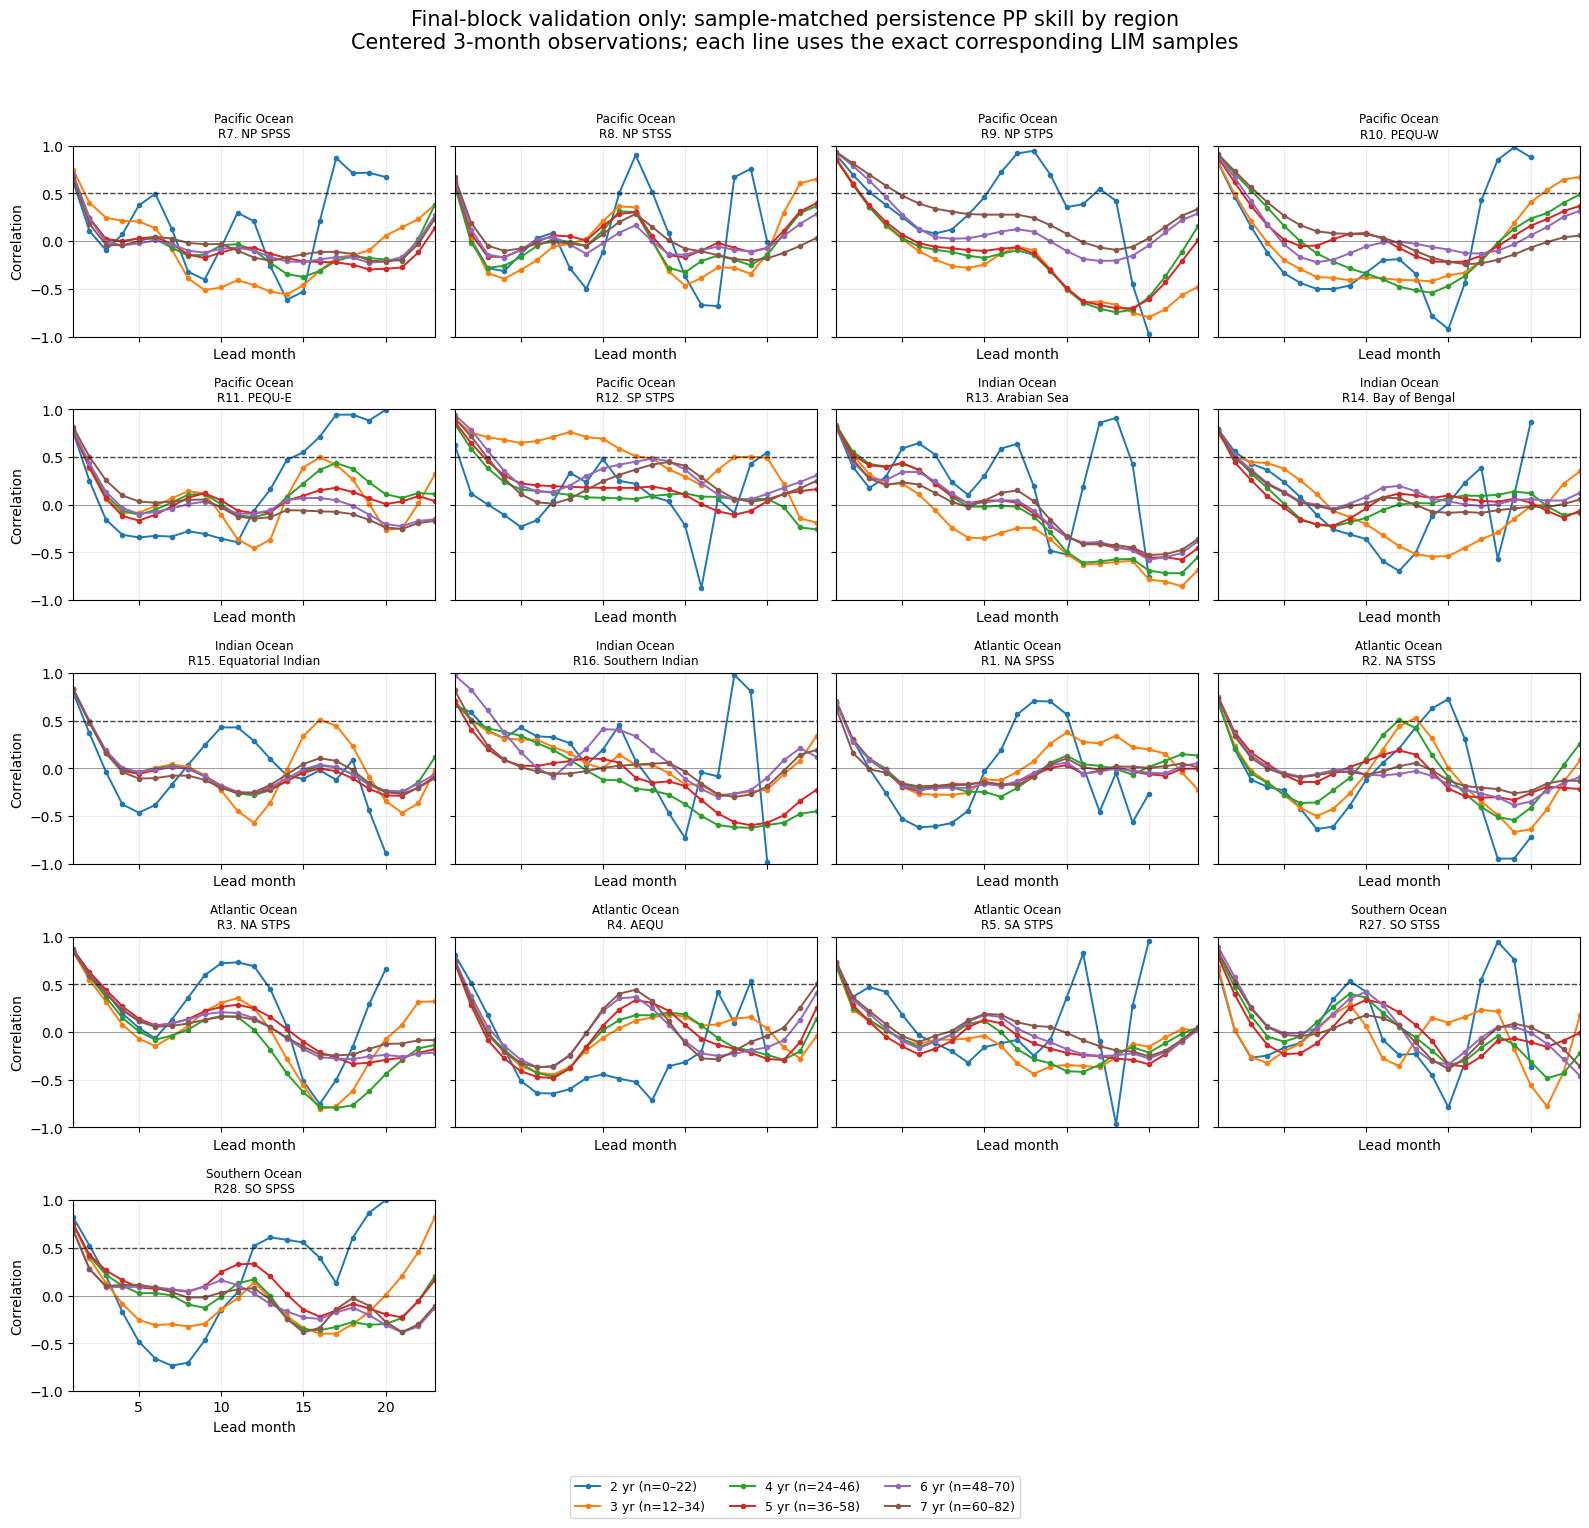

In [7]:
# ============================================================
# 6. Regional line panels: six window lengths in each region
# ============================================================

for design, design_info in designs.items():

    ncol = 4

    nrow = int(
        np.ceil(
            n_region_plot / ncol
        )
    )


    fig, axes = plt.subplots(
        nrow,
        ncol,
        figsize=(
            16,
            3.0 * nrow,
        ),
        sharex=True,
        sharey=True,
    )

    axes = np.asarray(
        axes
    ).ravel()


    for ax, region in zip(
        axes,
        regions_plot,
    ):

        for window_years in WINDOW_YEARS:
            window_years = int(
                window_years
            )

            ds_this = persistence_datasets[
                design
            ][window_years]

            skill = (
                ds_this[
                    "PP_correlation_skill_persistence"
                ]
                .sel(region=region)
            )

            n_pairs = (
                ds_this["n_pairs"]
                .sel(region=region)
                .values
                .astype(float)
            )

            finite_n = n_pairs[
                np.isfinite(n_pairs)
            ]

            n_text = (
                f"{int(np.nanmin(finite_n))}–"
                f"{int(np.nanmax(finite_n))}"
                if finite_n.size
                else "NA"
            )


            ax.plot(
                leads,
                skill.values,
                marker="o",
                lw=1.4,
                ms=3,
                label=(
                    f"{window_years} yr "
                    f"(n={n_text})"
                ),
            )


        ax.axhline(
            THRESHOLD,
            color="k",
            lw=1.0,
            ls="--",
            alpha=0.7,
        )

        ax.axhline(
            0,
            color="k",
            lw=0.6,
            alpha=0.4,
        )


        ax.set_title(
            f"{region_basin[int(region)]}\n"
            f"{get_region_label(reference_ds, region, short=True)}",
            fontsize=8.5,
        )

        ax.set_xlim(
            leads[0],
            leads[-1],
        )

        ax.set_ylim(
            -1,
            1,
        )

        ax.grid(
            alpha=0.25
        )


    for ax in axes[
        n_region_plot:
    ]:
        ax.axis("off")


    for index, ax in enumerate(
        axes[:n_region_plot]
    ):
        ax.set_xlabel(
            "Lead month"
        )

        if index % ncol == 0:
            ax.set_ylabel(
                "Correlation"
            )


    handles, labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=3,
        bbox_to_anchor=(
            0.5,
            -0.005,
        ),
        fontsize=9,
    )


    fig.suptitle(
        f"{design_info['title']}: sample-matched persistence PP skill by region\n"
        "Centered 3-month observations; each line uses the exact corresponding LIM samples",
        fontsize=15,
        y=1.005,
    )


    fig.tight_layout(
        rect=[
            0,
            0.045,
            1,
            0.985,
        ]
    )


    line_file = FIG_DIR / (
        f"Persistence_PP_samplematched_{design}_"
        "2to7year_regional_lines.png"
    )


    if SAVE_FIGURES:
        fig.savefig(
            line_file,
            dpi=200,
            bbox_inches="tight",
        )

        print(
            f"Saved: {line_file}"
        )


    plt.show()

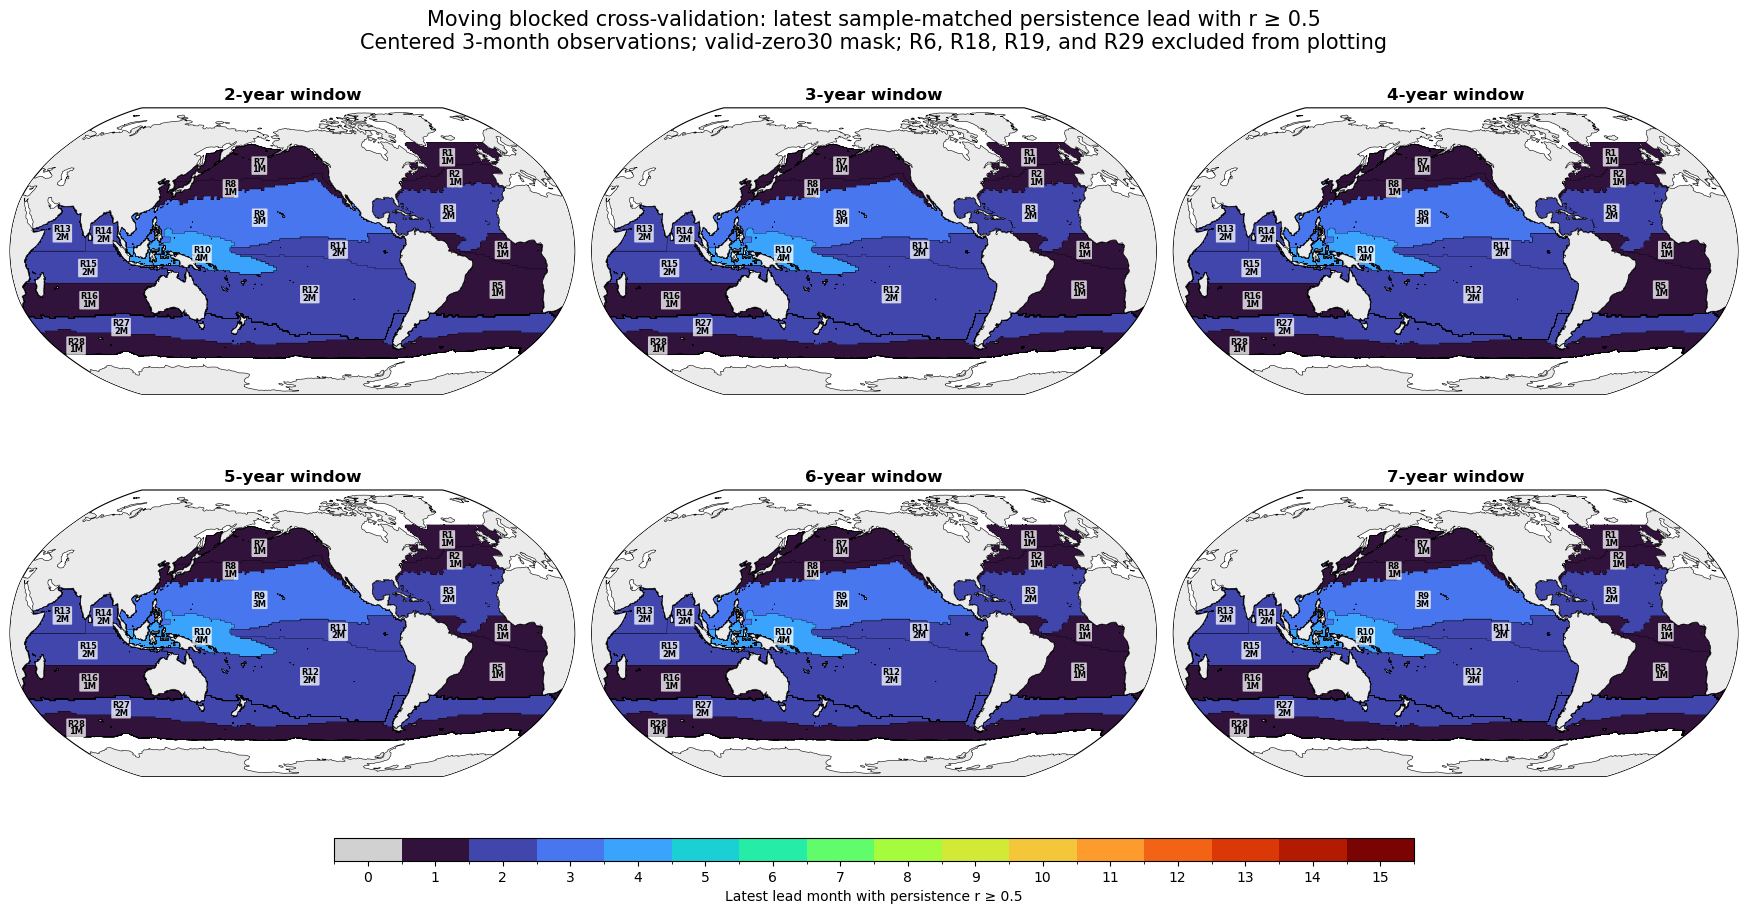

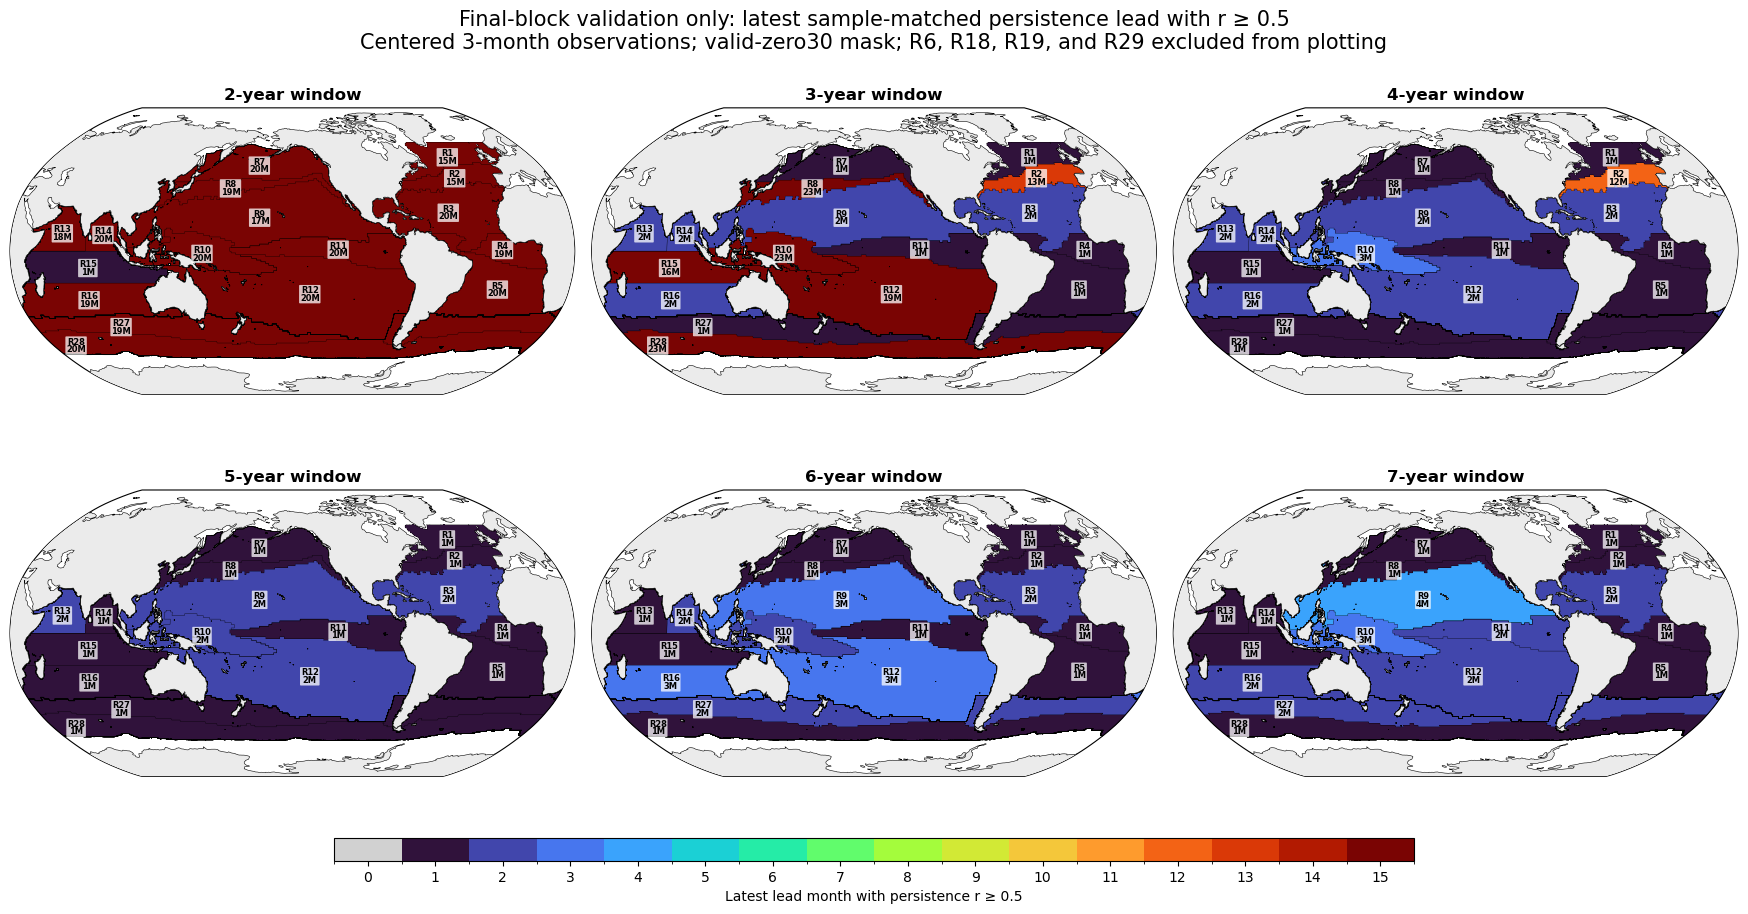

In [8]:
# ============================================================
# 7. Global maps: latest lead anywhere with persistence r >= 0.5
# ============================================================

if not VALID_MASK_FILE.exists():
    raise FileNotFoundError(
        f"Valid mask file not found:\n"
        f"{VALID_MASK_FILE}"
    )


with xr.open_dataset(
    VALID_MASK_FILE
) as ds:
    ds_mask = ds.load()


mask = ds_mask[
    "valid_region_mask"
]

lat = ds_mask[
    "latitude"
].values.astype(float)

lon = ds_mask[
    "longitude"
].values.astype(float)

mask_values = mask.values.astype(
    np.int16
)


mask_plot_full = mask_values.copy()

for excluded_region in EXCLUDE_REGIONS:
    mask_plot_full[
        mask_plot_full
        == excluded_region
    ] = 0


lat_plot = lat[
    ::PLOT_STRIDE
]

lon_plot = lon[
    ::PLOT_STRIDE
]

mask_plot = mask_plot_full[
    ::PLOT_STRIDE,
    ::PLOT_STRIDE,
].astype(float)

mask_cyclic, lon_cyclic = (
    add_cyclic_manual(
        mask_plot,
        lon_plot,
    )
)


remaining_regions = np.unique(
    mask_plot_full[
        mask_plot_full > 0
    ]
)

boundary_levels = np.arange(
    0.5,
    int(
        np.nanmax(
            remaining_regions
        )
    )
    + 1.5,
    1.0,
)


bounds = np.arange(
    -0.5,
    DISPLAY_MAX_LEAD + 1.5,
    1.0,
)


try:
    base_cmap = plt.get_cmap(
        "turbo",
        DISPLAY_MAX_LEAD,
    )
except ValueError:
    base_cmap = plt.get_cmap(
        "plasma",
        DISPLAY_MAX_LEAD,
    )


colors = (
    [
        (
            0.82,
            0.82,
            0.82,
            1.0,
        )
    ]
    + [
        base_cmap(index)
        for index
        in range(
            DISPLAY_MAX_LEAD
        )
    ]
)


map_cmap = ListedColormap(
    colors
)

map_cmap.set_bad(
    (
        1,
        1,
        1,
        0,
    )
)

map_norm = BoundaryNorm(
    bounds,
    map_cmap.N,
)


for design, design_info in designs.items():

    fig, axes = plt.subplots(
        2,
        3,
        figsize=(
            18,
            9.2,
        ),
        subplot_kw={
            "projection": (
                ccrs.Robinson(
                    central_longitude=(
                        CENTRAL_LONGITUDE
                    )
                )
            )
        },
    )

    axes = axes.ravel()

    last_image = None


    for ax, window_years in zip(
        axes,
        WINDOW_YEARS,
    ):

        window_years = int(
            window_years
        )

        ds_this = persistence_datasets[
            design
        ][window_years]

        latest = ds_this[
            "latest_lead_corr_ge_05_persistence"
        ]


        regions_to_map = [
            int(region)
            for region
            in latest["region"].values
            if (
                int(region)
                not in EXCLUDE_REGIONS
                and np.any(
                    mask_plot_full
                    == int(region)
                )
            )
        ]


        latest_plot = latest.sel(
            region=regions_to_map
        )


        lead_map = np.full(
            mask_values.shape,
            np.nan,
            dtype=np.float32,
        )


        for region in regions_to_map:
            value = float(
                latest_plot
                .sel(region=region)
                .values
            )

            lead_map[
                mask_plot_full
                == region
            ] = value


        lead_plot = lead_map[
            ::PLOT_STRIDE,
            ::PLOT_STRIDE,
        ]


        lead_cyclic, _ = (
            add_cyclic_manual(
                lead_plot,
                lon_plot,
            )
        )


        lead_cyclic_display = np.where(
            np.isfinite(
                lead_cyclic
            ),
            np.minimum(
                lead_cyclic,
                DISPLAY_MAX_LEAD,
            ),
            np.nan,
        )


        last_image = ax.pcolormesh(
            lon_cyclic,
            lat_plot,
            lead_cyclic_display,
            cmap=map_cmap,
            norm=map_norm,
            shading="auto",
            transform=ccrs.PlateCarree(),
        )


        ax.contour(
            lon_cyclic,
            lat_plot,
            mask_cyclic,
            levels=boundary_levels,
            colors="k",
            linewidths=0.25,
            transform=ccrs.PlateCarree(),
        )


        ax.add_feature(
            cfeature.LAND,
            facecolor="0.92",
            edgecolor="none",
            zorder=3,
        )

        ax.coastlines(
            linewidth=0.40,
            zorder=4,
        )

        ax.set_global()

        ax.set_title(
            f"{window_years}-year window",
            fontsize=12,
            fontweight="bold",
        )


        for region in regions_to_map:

            region_mask = (
                mask_plot_full
                == region
            )

            lon_c, lat_c = (
                weighted_centroid(
                    lon,
                    lat,
                    region_mask,
                )
            )


            if not (
                np.isfinite(lon_c)
                and np.isfinite(lat_c)
            ):
                continue


            value = int(
                latest_plot
                .sel(region=region)
                .values
            )


            ax.text(
                lon_to_180(lon_c),
                lat_c,
                f"R{region}\n{value}M",
                transform=ccrs.PlateCarree(),
                ha="center",
                va="center",
                fontsize=6.0,
                fontweight="bold",
                linespacing=0.82,
                bbox={
                    "facecolor": "white",
                    "edgecolor": "none",
                    "alpha": 0.75,
                    "boxstyle": (
                        "round,pad=0.10"
                    ),
                },
                zorder=5,
            )


    fig.suptitle(
        f"{design_info['title']}: latest sample-matched persistence lead with r ≥ 0.5\n"
        "Centered 3-month observations; valid-zero30 mask; "
        "R6, R18, R19, and R29 excluded from plotting",
        fontsize=15,
        y=0.98,
    )


    fig.subplots_adjust(
        left=0.02,
        right=0.98,
        top=0.91,
        bottom=0.11,
        wspace=0.03,
        hspace=0.08,
    )


    color_axis = fig.add_axes(
        [
            0.20,
            0.055,
            0.60,
            0.025,
        ]
    )


    colorbar = fig.colorbar(
        last_image,
        cax=color_axis,
        orientation="horizontal",
        ticks=np.arange(
            0,
            DISPLAY_MAX_LEAD + 1,
            1,
        ),
        boundaries=bounds,
    )


    colorbar.set_label(
        "Latest lead month with persistence r ≥ 0.5"
    )


    map_file = FIG_DIR / (
        f"Persistence_PP_samplematched_{design}_"
        "2to7year_latest_corr_ge_05_maps.png"
    )


    if SAVE_FIGURES:
        fig.savefig(
            map_file,
            dpi=200,
            bbox_inches="tight",
        )

        print(
            f"Saved: {map_file}"
        )


    plt.show()